# Plant NeRF — COLMAP vs MASt3R comparison (fixed)

Reads the two already-trained, already-saved runs straight from Drive
(produced by `nerf_colmap.ipynb` and `nerf_mast3r.ipynb`) and runs the
quantitative + geometric comparison. No training happens here.

**Fixes in this version**
- One single config cell with the **4 paths** you actually need: COLMAP metrics json,
  MASt3R metrics json, COLMAP point cloud `.ply`, MASt3R point cloud `.ply`.
- Both point clouds are normalized to a **common frame** before comparison:
  centered on the same origin, rescaled to the same size, then fine-aligned with ICP.
- Both point clouds get a **180° flip** applied (they were upside down — plant tip at
  the bottom, roots/pot at the top). Each cloud has its own on/off flag in case only
  one of them actually needs it.
- Nicer plots: metrics bar chart, % difference chart, distance histogram, and
  matplotlib snapshots of the clouds before/after alignment so you can *see* that the
  flip + alignment worked, not just trust a number.


In [1]:
# CELL 1 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')

import os
WORK = "/content/work"
os.makedirs(WORK, exist_ok=True)


Mounted at /content/drive


In [15]:
# CELL 2 — CONFIG: the 4 paths you edit, plus the flip/orientation switches
# -----------------------------------------------------------------------
# Just point these at the outputs already produced by nerf_colmap.ipynb / nerf_mast3r.ipynb

COLMAP_METRICS_PATH = "/content/drive/MyDrive/jetcobot_colab/compare/colmap_metrics.json"
MAST3R_METRICS_PATH = "/content/drive/MyDrive/jetcobot_colab/compare/mast3r_metrics.json"

COLMAP_PLY_PATH = "/content/drive/MyDrive/jetcobot_colab/compare/fused_cleaned.ply"
MAST3R_PLY_PATH = "/content/drive/MyDrive/jetcobot_colab/compare/plant_pointcloud.ply"

DRIVE_OUT = "/content/drive/MyDrive/jetcobot_colab/compare/result2"
os.makedirs(DRIVE_OUT, exist_ok=True)

# --- orientation fix -----------------------------------------------------
# Both clouds came out upside down (plant top at the bottom, pot/roots at the top).
# FLIP_AXIS is the axis you rotate 180Â° around to fix that. Up is Z in nerfstudio
# exports, and rotating 180Â° about X flips Z (up/down) and Y (depth) while leaving
# X (left/right) alone -- that's the standard "flip upside down" fix.
FLIP_AXIS    = "x"     # 'x', 'y', or 'z' -- axis to rotate 180 degrees around
FLIP_COLMAP  = True    # set False if this one turns out to already be right-side up
FLIP_MAST3R  = True    # set False if this one turns out to already be right-side up

print("COLMAP metrics:", COLMAP_METRICS_PATH)
print("MASt3R metrics:", MAST3R_METRICS_PATH)
print("COLMAP ply:    ", COLMAP_PLY_PATH)
print("MASt3R ply:    ", MAST3R_PLY_PATH)
print("Output folder: ", DRIVE_OUT)


COLMAP metrics: /content/drive/MyDrive/jetcobot_colab/compare/colmap_metrics.json
MASt3R metrics: /content/drive/MyDrive/jetcobot_colab/compare/mast3r_metrics.json
COLMAP ply:     /content/drive/MyDrive/jetcobot_colab/compare/fused_cleaned.ply
MASt3R ply:     /content/drive/MyDrive/jetcobot_colab/compare/plant_pointcloud.ply
Output folder:  /content/drive/MyDrive/jetcobot_colab/compare/result2


In [3]:
# CELL 3 — Install comparison-only deps
!pip install -q open3d trimesh pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 85.7 MB/s eta 0:00:00


In [16]:
# CELL 4 — Load the metrics already computed by the two training notebooks
import json

eval_dir = os.path.join(WORK, "eval")
os.makedirs(eval_dir, exist_ok=True)

with open(COLMAP_METRICS_PATH) as f: colmap_metrics = json.load(f)
with open(MAST3R_METRICS_PATH) as f: mast3r_metrics = json.load(f)

def flat(m):
    return m.get("results", m)

print(json.dumps(flat(colmap_metrics), indent=2))
print(json.dumps(flat(mast3r_metrics), indent=2))


{
  "psnr": 19.929489135742188,
  "psnr_std": 4.6852264404296875,
  "ssim": 0.7906454205513,
  "ssim_std": 0.07555194199085236,
  "lpips": 0.16015847027301788,
  "lpips_std": 0.18360859155654907,
  "num_rays_per_sec": 29417.68359375,
  "num_rays_per_sec_std": 586.3195190429688,
  "fps": 0.09576069563627243,
  "fps_std": 0.001908592996187508
}
{
  "psnr": 14.1702299118042,
  "psnr_std": 3.225703001022339,
  "ssim": 0.5549790859222412,
  "ssim_std": 0.06946374475955963,
  "lpips": 0.41964638233184814,
  "lpips_std": 0.1667141616344452,
  "num_rays_per_sec": 29184.025390625,
  "num_rays_per_sec_std": 702.4030151367188,
  "fps": 0.09500008076429367,
  "fps_std": 0.002286468632519245
}


,metric,colmap,mast3r,diff (colmap - mast3r),% diff (vs colmap)
0,fps,0.095761,0.095000,0.000761,0.794287
1,fps_std,0.001909,0.002286,-0.000378,-19.798649
2,lpips,0.160158,0.419646,-0.259488,-162.019475
3,lpips_std,0.183609,0.166714,0.016894,9.201329
4,num_rays_per_sec,29417.683594,29184.025391,233.658203,0.794278
5,num_rays_per_sec_std,586.319519,702.403015,-116.083496,-19.798675
6,psnr,19.929489,14.170230,5.759259,28.898178
7,psnr_std,4.685226,3.225703,1.459523,31.151609
8,ssim,0.790645,0.554979,0.235666,29.806830
9,ssim_std,0.075552,0.069464,0.006088,8.058294


/tmp/ipykernel_2284/1293946313.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(df["metric"], rotation=30, ha="right")


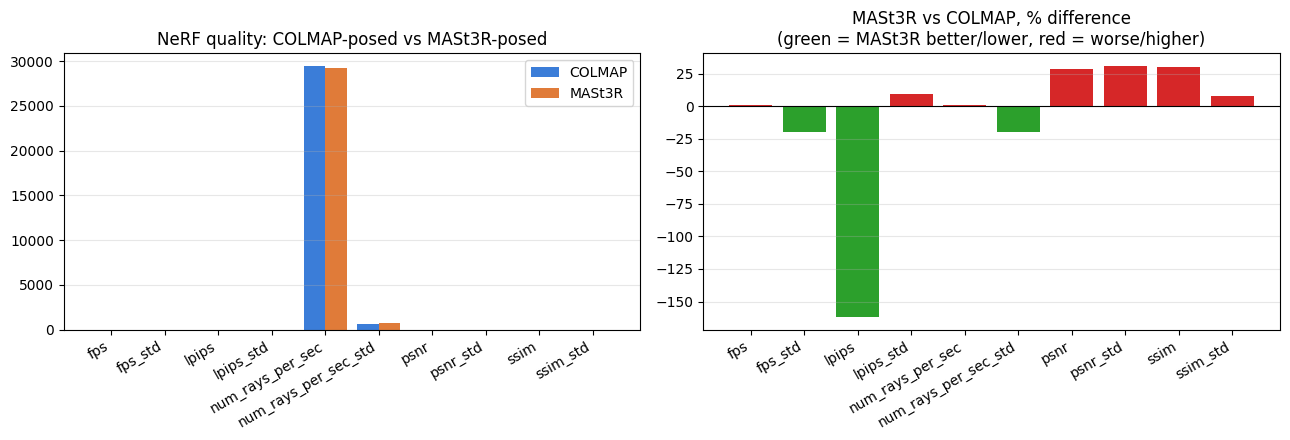

In [17]:
# CELL 5 — Side-by-side metrics table, bar chart, % difference chart
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

c, m = flat(colmap_metrics), flat(mast3r_metrics)
keys = sorted(set(c.keys()) & set(m.keys()))

df = pd.DataFrame({
    "metric": keys,
    "colmap": [c[k] for k in keys],
    "mast3r": [m[k] for k in keys],
})
df["diff (colmap - mast3r)"] = df["colmap"] - df["mast3r"]
df["% diff (vs colmap)"] = 100 * df["diff (colmap - mast3r)"] / df["colmap"].replace(0, np.nan)
display(df)
df.to_csv(os.path.join(eval_dir, "metrics_comparison.csv"), index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x = range(len(df))
axes[0].bar([i - 0.2 for i in x], df["colmap"], width=0.4, label="COLMAP", color="#3b7dd8")
axes[0].bar([i + 0.2 for i in x], df["mast3r"], width=0.4, label="MASt3R", color="#e07b39")
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(df["metric"], rotation=30, ha="right")
axes[0].legend(); axes[0].set_title("NeRF quality: COLMAP-posed vs MASt3R-posed")
axes[0].grid(axis="y", alpha=0.3)

colors = ["#2ca02c" if v <= 0 else "#d62728" for v in df["% diff (vs colmap)"].fillna(0)]
axes[1].bar(df["metric"], df["% diff (vs colmap)"].fillna(0), color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticklabels(df["metric"], rotation=30, ha="right")
axes[1].set_title("MASt3R vs COLMAP, % difference\n(green = MASt3R better/lower, red = worse/higher)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(eval_dir, "metrics_comparison.png"), dpi=150)
plt.show()


COLMAP: 367107 pts | flip=True | scale=0.14438
MASt3R: 1715105 pts | flip=True | extra_rotate=z:-90 | scale=0.33514
ICP fitness: 0.8990712074303405 | inlier RMSE: 0.022831188140676105


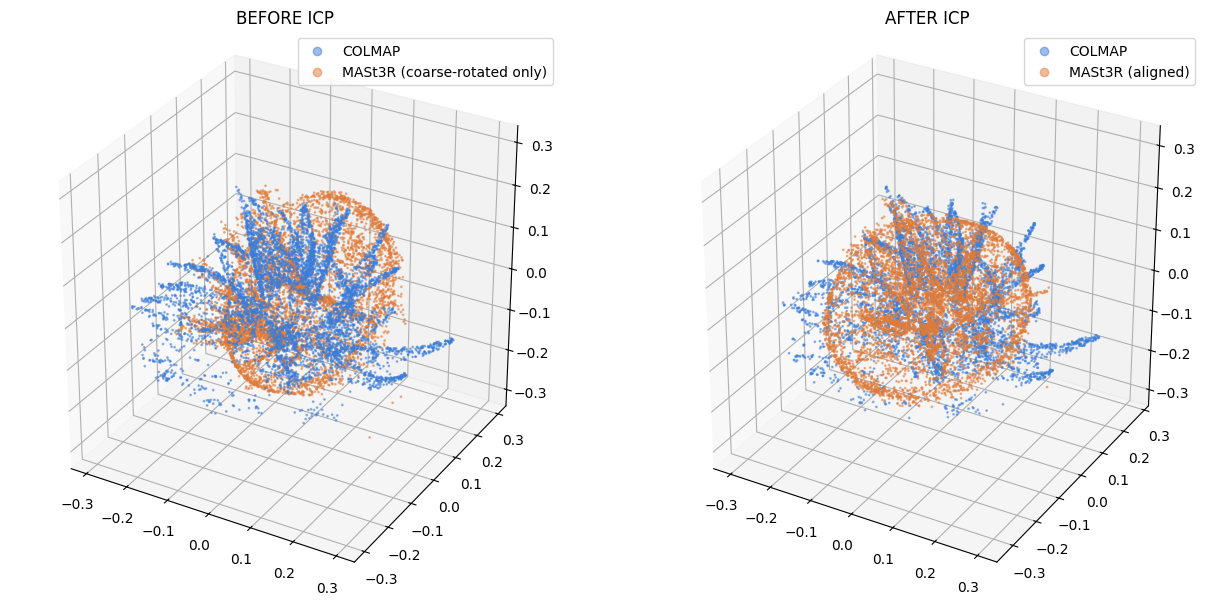

In [18]:
# CELL 6 — Load point clouds, normalize, coarse-rotate, and ALIGN mast3r onto colmap
import open3d as o3d
import glob
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def load_ply(path):
    if not os.path.isdir(path) and os.path.exists(path):
        return o3d.io.read_point_cloud(path)
    cands = glob.glob(os.path.join(path, "**", "*.ply"), recursive=True)
    if not cands:
        raise FileNotFoundError(f"No .ply found at or under {path}")
    return o3d.io.read_point_cloud(cands[0])

def rotate_pcd(pcd, axis, degrees):
    """Rotate about the cloud's own centroid by an arbitrary angle around x/y/z."""
    rad = np.deg2rad(degrees)
    if axis == "x":
        R = pcd.get_rotation_matrix_from_axis_angle([rad, 0, 0])
    elif axis == "y":
        R = pcd.get_rotation_matrix_from_axis_angle([0, rad, 0])
    else:
        R = pcd.get_rotation_matrix_from_axis_angle([0, 0, rad])
    pcd.rotate(R, center=pcd.get_center())
    return pcd

def normalize_pcd(pcd, flip=False, flip_axis="x", extra_rotate=None):
    """Center at origin, rescale to unit bbox diagonal. Optionally 180-flip, then
    optionally apply one more coarse rotation (axis, degrees) to fix orientations
    ICP can't recover on its own (e.g. a ~90 deg mismatch)."""
    pcd = o3d.geometry.PointCloud(pcd)  # copy, don't mutate original
    if flip:
        pcd = rotate_pcd(pcd, flip_axis, 180)
    if extra_rotate is not None:
        ex_axis, ex_deg = extra_rotate
        pcd = rotate_pcd(pcd, ex_axis, ex_deg)
    center = pcd.get_center()
    pcd.translate(-center)
    bbox = pcd.get_axis_aligned_bounding_box()
    diag = np.linalg.norm(bbox.get_max_bound() - bbox.get_min_bound())
    scale = 1.0 / diag if diag > 0 else 1.0
    pcd.scale(scale, center=(0, 0, 0))
    return pcd, {"center": center.tolist(), "scale": scale}

# --- MASt3R looked rotated ~90deg clockwise (viewed from above) vs COLMAP ---
# Try -90 first; if it overshoots/undershoots, flip the sign or try 180.
MAST3R_EXTRA_ROTATE_AXIS = "z"
MAST3R_EXTRA_ROTATE_DEG  = -90

# --- load + normalize (center, scale, flip, coarse-rotate) each cloud ---
pcd_colmap_raw = load_ply(COLMAP_PLY_PATH)
pcd_mast3r_raw = load_ply(MAST3R_PLY_PATH)

pcd_colmap, colmap_xform = normalize_pcd(pcd_colmap_raw, flip=FLIP_COLMAP, flip_axis=FLIP_AXIS)
pcd_mast3r_unaligned, mast3r_xform = normalize_pcd(
    pcd_mast3r_raw, flip=FLIP_MAST3R, flip_axis=FLIP_AXIS,
    extra_rotate=(MAST3R_EXTRA_ROTATE_AXIS, MAST3R_EXTRA_ROTATE_DEG)
)

# --- ALIGN: register mast3r onto colmap's frame (fine cleanup on top of the coarse rotation) ---
voxel = 0.01
c_ds = pcd_colmap.voxel_down_sample(voxel)
m_ds = pcd_mast3r_unaligned.voxel_down_sample(voxel)
c_ds.estimate_normals(); m_ds.estimate_normals()

reg_coarse = o3d.pipelines.registration.registration_icp(
    m_ds, c_ds, max_correspondence_distance=voxel * 15,
    estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint()
)
reg = o3d.pipelines.registration.registration_icp(
    m_ds, c_ds, max_correspondence_distance=voxel * 5,
    init=reg_coarse.transformation,
    estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPlane()
)

pcd_mast3r = o3d.geometry.PointCloud(pcd_mast3r_unaligned)
pcd_mast3r.transform(reg.transformation)

print(f"COLMAP: {len(pcd_colmap_raw.points)} pts | flip={FLIP_COLMAP} | scale={colmap_xform['scale']:.5f}")
print(f"MASt3R: {len(pcd_mast3r_raw.points)} pts | flip={FLIP_MAST3R} | "
      f"extra_rotate={MAST3R_EXTRA_ROTATE_AXIS}:{MAST3R_EXTRA_ROTATE_DEG} | scale={mast3r_xform['scale']:.5f}")
print("ICP fitness:", reg.fitness, "| inlier RMSE:", reg.inlier_rmse)

# --- PROOF: overlay both clouds on the SAME shared, equal-scale axes ---
def overlay_plot(ax, pcd_a, pcd_b, label_a, label_b, title, n=6000):
    pts_a = np.asarray(pcd_a.points)
    pts_b = np.asarray(pcd_b.points)
    if len(pts_a) > n: pts_a = pts_a[np.random.choice(len(pts_a), n, replace=False)]
    if len(pts_b) > n: pts_b = pts_b[np.random.choice(len(pts_b), n, replace=False)]
    all_pts = np.vstack([pts_a, pts_b])
    center = all_pts.mean(axis=0)
    half_range = (all_pts.max(axis=0) - all_pts.min(axis=0)).max() / 2 * 1.05
    ax.scatter(pts_a[:, 0], pts_a[:, 2], pts_a[:, 1], s=1, alpha=0.5, color="#3b7dd8", label=label_a)
    ax.scatter(pts_b[:, 0], pts_b[:, 2], pts_b[:, 1], s=1, alpha=0.5, color="#e07b39", label=label_b)
    ax.set_xlim(center[0]-half_range, center[0]+half_range)
    ax.set_ylim(center[2]-half_range, center[2]+half_range)
    ax.set_zlim(center[1]-half_range, center[1]+half_range)
    ax.set_box_aspect((1,1,1))
    ax.set_title(title); ax.legend(markerscale=6)

fig = plt.figure(figsize=(13, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
overlay_plot(ax1, pcd_colmap, pcd_mast3r_unaligned, "COLMAP", "MASt3R (coarse-rotated only)", "BEFORE ICP")
overlay_plot(ax2, pcd_colmap, pcd_mast3r, "COLMAP", "MASt3R (aligned)", "AFTER ICP")
plt.tight_layout()
plt.show()

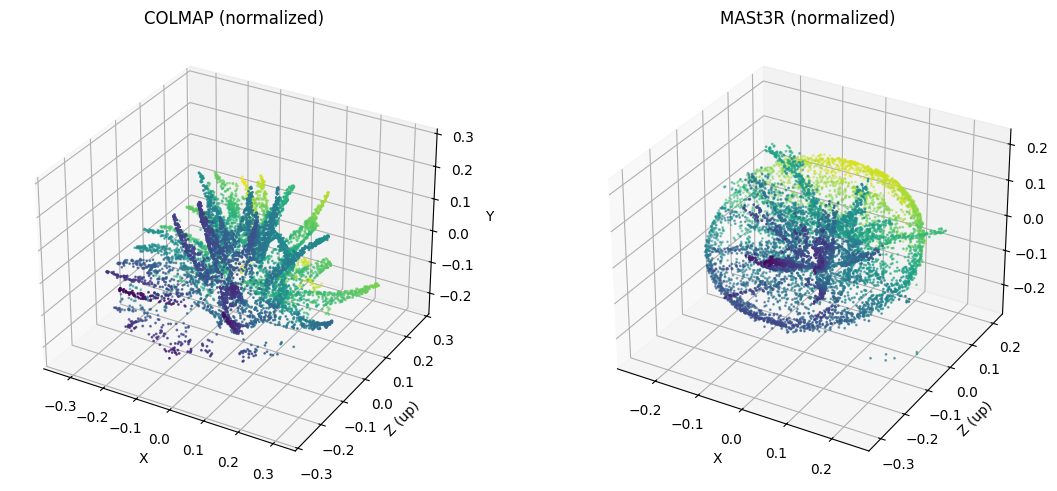

If the canopy is still at the bottom here, flip the corresponding FLIP_* flag in Cell 2 (or try FLIP_AXIS = 'y') and re-run from Cell 6.


In [19]:
# CELL 7 — Sanity-check the orientation visually (before fine alignment)
# Quick matplotlib snapshots, colored by height (Z), so an upside-down cloud is obvious:
# the plant canopy (most points / widest spread) should be near the TOP of the plot.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def quick_snapshot(ax, pcd, title, n=8000):
    pts = np.asarray(pcd.points)
    if len(pts) > n:
        idx = np.random.choice(len(pts), n, replace=False)
        pts = pts[idx]
    ax.scatter(pts[:, 0], pts[:, 2], pts[:, 1], s=1, c=pts[:, 2], cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("X"); ax.set_ylabel("Z (up)"); ax.set_zlabel("Y")

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
quick_snapshot(ax1, pcd_colmap, "COLMAP (normalized)")
quick_snapshot(ax2, pcd_mast3r, "MASt3R (normalized)")
plt.tight_layout()
plt.savefig(os.path.join(eval_dir, "orientation_check.png"), dpi=150)
plt.show()
print("If the canopy is still at the bottom here, flip the corresponding FLIP_* flag "
      "in Cell 2 (or try FLIP_AXIS = 'y') and re-run from Cell 6.")


In [20]:
import numpy as np
import open3d as o3d
import json
import os

# CELL 8 — Geometric comparison: fine ICP alignment + Chamfer distance + error heatmap
# Coarse alignment (same origin, same scale, right-side up) is already done in Cell 6;
# this just removes any small residual rotation/translation before measuring distance.
voxel = 0.01  # in normalized units (unit bbox diagonal), so this is a fixed fraction of cloud size

c_ds = pcd_colmap.voxel_down_sample(voxel)
m_ds = pcd_mast3r.voxel_down_sample(voxel)
c_ds.estimate_normals(); m_ds.estimate_normals()

reg = o3d.pipelines.registration.registration_icp(
    m_ds, c_ds, max_correspondence_distance=voxel * 5,
    estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPlane()
)
pcd_mast3r_aligned = o3d.geometry.PointCloud(pcd_mast3r)
pcd_mast3r_aligned.transform(reg.transformation)
print("ICP fitness:", reg.fitness, "| inlier RMSE:", reg.inlier_rmse)
if reg.fitness < 0.3:
    print("WARNING: low ICP fitness (<0.3) -- the two clouds did not align well even after "
          "flip + rescale. That's a real signal (scale/drift issue in one pose source), not just noise.")

dists_m_to_c = np.asarray(pcd_mast3r_aligned.compute_point_cloud_distance(pcd_colmap))
dists_c_to_m = np.asarray(pcd_colmap.compute_point_cloud_distance(pcd_mast3r_aligned))
chamfer = dists_m_to_c.mean() + dists_c_to_m.mean()
print(f"Chamfer distance (colmap <-> mast3r, normalized units): {chamfer:.5f}")

d = dists_m_to_c
d_norm = (d - d.min()) / (np.ptp(d) + 1e-9)
colors = np.stack([d_norm, 1 - d_norm, np.zeros_like(d_norm)], axis=1)
pcd_mast3r_aligned.colors = o3d.utility.Vector3dVector(colors)

geo_compare_dir = os.path.join(WORK, "geometry_comparison")
os.makedirs(geo_compare_dir, exist_ok=True)
o3d.io.write_point_cloud(os.path.join(geo_compare_dir, "mast3r_aligned_to_colmap.ply"), pcd_mast3r_aligned)
o3d.io.write_point_cloud(os.path.join(geo_compare_dir, "colmap_reference.ply"), pcd_colmap)

with open(os.path.join(geo_compare_dir, "geometry_comparison_summary.json"), "w") as f:
    json.dump({
        "flip_axis": FLIP_AXIS,
        "flip_colmap": FLIP_COLMAP,
        "flip_mast3r": FLIP_MAST3R,
        "colmap_normalization": colmap_xform,
        "mast3r_normalization": mast3r_xform,
        "icp_fitness": reg.fitness,
        "icp_inlier_rmse": reg.inlier_rmse,
        "chamfer_distance": float(chamfer),
        "mean_dist_mast3r_to_colmap": float(dists_m_to_c.mean()),
        "mean_dist_colmap_to_mast3r": float(dists_c_to_m.mean()),
    }, f, indent=2)

print("Saved heatmap ply + summary to", geo_compare_dir)


ICP fitness: 0.9185479375696767 | inlier RMSE: 0.022882972348792597
Chamfer distance (colmap <-> mast3r, normalized units): 0.05350
Saved heatmap ply + summary to /content/work/geometry_comparison


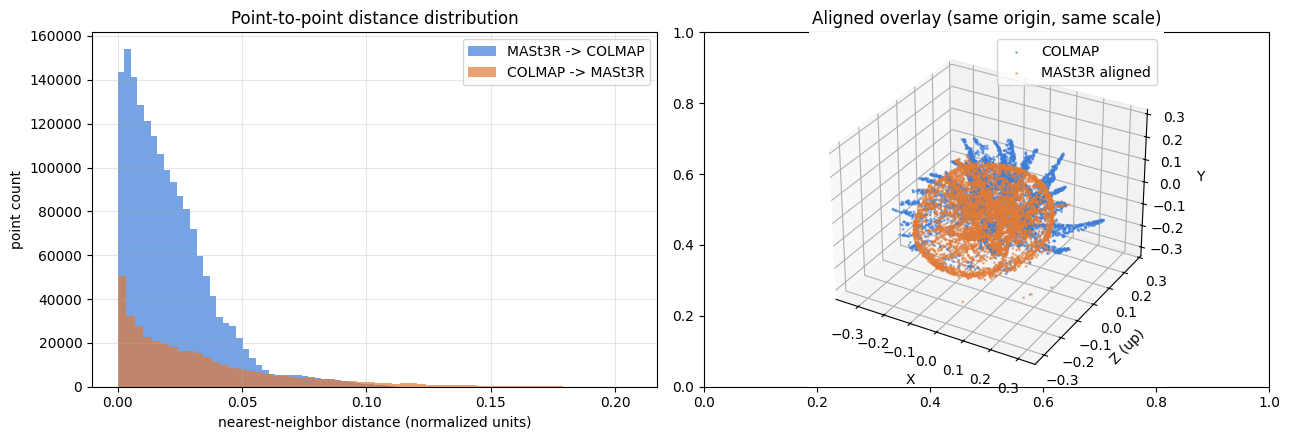

In [21]:
# CELL 9 — More plots: distance histogram + aligned overlay snapshot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(dists_m_to_c, bins=60, color="#3b7dd8", alpha=0.7, label="MASt3R -> COLMAP")
axes[0].hist(dists_c_to_m, bins=60, color="#e07b39", alpha=0.7, label="COLMAP -> MASt3R")
axes[0].set_xlabel("nearest-neighbor distance (normalized units)")
axes[0].set_ylabel("point count")
axes[0].set_title("Point-to-point distance distribution")
axes[0].legend(); axes[0].grid(alpha=0.3)

ax = fig.add_subplot(1, 2, 2, projection="3d")
pts_c = np.asarray(pcd_colmap.points)
pts_m = np.asarray(pcd_mast3r_aligned.points)
for pts, label, color in [(pts_c, "COLMAP", "#3b7dd8"), (pts_m, "MASt3R aligned", "#e07b39")]:
    if len(pts) > 6000:
        idx = np.random.choice(len(pts), 6000, replace=False)
        pts = pts[idx]
    ax.scatter(pts[:, 0], pts[:, 2], pts[:, 1], s=1, alpha=0.5, label=label, color=color)
ax.set_title("Aligned overlay (same origin, same scale)")
ax.set_xlabel("X"); ax.set_ylabel("Z (up)"); ax.set_zlabel("Y")
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(eval_dir, "distance_hist_and_overlay.png"), dpi=150)
plt.show()


In [22]:
# CELL 10 — Save everything to Drive
import shutil

final_dir = os.path.join(DRIVE_OUT, "comparison_" + pd.Timestamp.now().strftime("%Y%m%d_%H%M%S"))
os.makedirs(final_dir, exist_ok=True)

shutil.copytree(eval_dir, os.path.join(final_dir, "evaluation"))
shutil.copytree(geo_compare_dir, os.path.join(final_dir, "geometry_comparison"))

with open(os.path.join(final_dir, "source_paths.json"), "w") as f:
    json.dump({
        "colmap_metrics_path": COLMAP_METRICS_PATH,
        "mast3r_metrics_path": MAST3R_METRICS_PATH,
        "colmap_ply_path": COLMAP_PLY_PATH,
        "mast3r_ply_path": MAST3R_PLY_PATH,
    }, f, indent=2)

print("COMPARISON RESULTS SAVED TO:", final_dir)
!ls -R {final_dir} | head -60


COMPARISON RESULTS SAVED TO: /content/drive/MyDrive/jetcobot_colab/compare/result2/comparison_20260725_000940
/content/drive/MyDrive/jetcobot_colab/compare/result2/comparison_20260725_000940:
evaluation
geometry_comparison
source_paths.json

/content/drive/MyDrive/jetcobot_colab/compare/result2/comparison_20260725_000940/evaluation:
distance_hist_and_overlay.png
metrics_comparison.csv
metrics_comparison.png
orientation_check.png

/content/drive/MyDrive/jetcobot_colab/compare/result2/comparison_20260725_000940/geometry_comparison:
colmap_reference.ply
geometry_comparison_summary.json
mast3r_aligned_to_colmap.ply


## Notes
- **CloudCompare / MeshLab / Blender**: open `geometry_comparison/*.ply` — the heatmap
  one (`mast3r_aligned_to_colmap.ply`) is the most informative single file: red regions
  are where MASt3R and COLMAP geometry disagree.
- Both clouds are normalized (centered at the origin, rescaled to the same bounding-box
  diagonal, flipped right-side up) **before** ICP and before the Chamfer distance is
  computed — so distances are comparable and not skewed by one cloud being bigger/offset.
- If the Cell 7 snapshot still shows the canopy at the bottom, flip `FLIP_COLMAP` /
  `FLIP_MAST3R` in Cell 2 (or try `FLIP_AXIS = 'y'`) and re-run from Cell 6.
- If `ICP fitness` is low (<0.3), the two point clouds didn't align well even after the
  fix — that's a real signal, not just noise: it usually means one pose source has a
  scale/drift problem MASt3R or COLMAP struggled with on this plant.
- This notebook never trains anything — if metrics/ply files are missing, re-run the
  corresponding training notebook first.
